# REVE + Convex-NN linear probe - K-trials calibration sweep (v3, source-anchored warm start)

Same REVE-matched preprocessing + attention-pooled features as `reve_kmin_convexnn_updated.ipynb`. **New in v3:** the convex-NN head is trained in two stages with ADMM warm-starting, but stage 2 is source-anchored instead of target-only.

**2-step training**:
1. **Stage 1 (source):** run ADMM on the source pool from the standard zero init. Save the final convex-program state `(u, v, lam)` from this solve.
2. **Stage 2 (subject):** build a *new* `CVX_ReLU_MLP` on `source + weighted K-per-class calibration trials` (same seed -> same random hyperplanes -> same neuron parameterization). Re-run ADMM from the stage-1 primal weights. The sample-shaped slack/dual variables `(s, nu)` are re-initialized, and the stationarity dual `lam` is reset by default.

The same `StandardScaler` from stage 1 is reused at stage 2 (don't refit it on `K * 4` points because that destroys the feature space the stage-1 weights live in). For K = 0 there is no calibration data, so the stage-1 model is used as the final predictor.

**Added comparisons:**
- EEGNet source pretraining plus calibration replay fine-tuning on the same K splits.
- A convex HP grid over `STAGE2_TARGET_MASS` and `CVX_BETA`.

## 0. Config

In [11]:
from __future__ import annotations

import sys, os, json, time, warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch

# --- paths ---
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
EEGMMI_DIR = REPO_ROOT / "data" / "raw" / "eegmmi"
CLD_DIR = REPO_ROOT / "vendor" / "CLD"
assert EEGMMI_DIR.exists(), f"missing dataset dir: {EEGMMI_DIR}"
assert CLD_DIR.exists(),    f"missing CLD vendor dir: {CLD_DIR}"

# --- sweep config ---
K_BUDGETS         = (0, 1, 2, 5, 10, 20)   # trials per class used for calibration
N_HELD_OUT        = 8                       # raise to 15 for the headline curve
SEED              = 0
TRIAL_TMIN        = 0.0
TRIAL_TMAX        = 4.0
TARGET_FS_REVE    = 200
HIGHPASS_HZ       = 0.3
NOTCH_HZ          = 60.0
SCALE_FACTOR      = 100.0
IMAGERY_RUNS      = (4, 6, 8, 10, 12, 14)
EXCLUDED_SUBJECTS = frozenset({88, 89, 92, 100, 104})

# --- ConvexNN head hparams ---
CVX_N_NEURONS  = 16
CVX_BETA       = 1.0e-3
CVX_RHO        = 0.1
CVX_ADMM_ITERS = 8        # iterations for stage-1 (source) solve
CVX_PCG_ITERS  = 32
CVX_RANK       = 20

# Stage 2 is a source-anchored adaptation problem, not a target-only refit.
STAGE2_ADMM_ITERS = 4
STAGE2_TARGET_MASS = 0.35     # target calibration share in the stage-2 weighted loss
STAGE2_WARM_START_DUAL = False  # stale ADMM duals are diagnostic-only for target-shifted problems

# --- ConvexNN HP grid ---
RUN_CVX_HP_GRID = True
CVX_BETA_GRID = (3.0e-4, 1.0e-3, 3.0e-3)
STAGE2_TARGET_MASS_GRID = (0.15, 0.35, 0.55)
HP_GRID_K_BUDGETS = tuple(k for k in K_BUDGETS if k > 0)

# --- EEGNet baseline hparams ---
RUN_EEGNET_BASELINE = True
EEGNET_BATCH_SIZE = 64
EEGNET_SOURCE_EPOCHS = 50
EEGNET_FINETUNE_EPOCHS = 12
EEGNET_PATIENCE = 8
EEGNET_LR = 1.0e-3
EEGNET_FINETUNE_LR = 3.0e-4
EEGNET_WEIGHT_DECAY = 1.0e-4
EEGNET_DROPOUT = 0.5
EEGNET_SOURCE_REPLAY_FRAC = 0.25  # cap source replay during per-subject fine-tuning
# EEGNet branch runs at 100 Hz (downsampled from REVE's 200 Hz) with kernel_len=100
# to match the receptive field implied by the EEGNet paper at fs=200 / src LOSO setup.
EEGNET_TARGET_FS = 100
EEGNET_KERNEL_LEN = 100
EEGNET_TRIAL_SAMPLES = int(round((TRIAL_TMAX - TRIAL_TMIN) * EEGNET_TARGET_FS))

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"device={DEVICE}  |  repo={REPO_ROOT}")

device=mps  |  repo=/Users/williamtan/Projects/cs229/etm_clf


## 1. Load EEGMMI from EDF (REVE-matched preprocessing)

Average re-reference, highpass 0.3 Hz, notch 60 Hz, resample to 200 Hz, epochs in microvolts, last 800 samples of the 4 s window.

In [12]:
import mne
mne.set_log_level("ERROR")

RUN_LABEL_MAP = {
    (4, "T1"): 0,  (8, "T1"): 0,  (12, "T1"): 0,
    (4, "T2"): 1,  (8, "T2"): 1,  (12, "T2"): 1,
    (6, "T1"): 2,  (10, "T1"): 2, (14, "T1"): 2,
    (6, "T2"): 3,  (10, "T2"): 3, (14, "T2"): 3,
}
CLASS_NAMES = ("LeftFist", "RightFist", "BothFists", "BothFeet")

EEGMMI_64 = (
    "Fc5","Fc3","Fc1","Fcz","Fc2","Fc4","Fc6",
    "C5","C3","C1","Cz","C2","C4","C6",
    "Cp5","Cp3","Cp1","Cpz","Cp2","Cp4","Cp6",
    "Fp1","Fpz","Fp2",
    "Af7","Af3","Afz","Af4","Af8",
    "F7","F5","F3","F1","Fz","F2","F4","F6","F8",
    "Ft7","Ft8",
    "T7","T8","T9","T10",
    "Tp7","Tp8",
    "P7","P5","P3","P1","Pz","P2","P4","P6","P8",
    "Po7","Po3","Poz","Po4","Po8",
    "O1","Oz","O2","Iz",
)

_REVE_NAME_MAP = {
    "Fc5":"FC5","Fc3":"FC3","Fc1":"FC1","Fcz":"FCz","Fc2":"FC2","Fc4":"FC4","Fc6":"FC6",
    "Cp5":"CP5","Cp3":"CP3","Cp1":"CP1","Cpz":"CPz","Cp2":"CP2","Cp4":"CP4","Cp6":"CP6",
    "Fp1":"FP1","Fp2":"FP2",
    "Af7":"AF7","Af3":"AF3","Afz":"AFz","Af4":"AF4","Af8":"AF8",
    "Ft7":"FT7","Ft8":"FT8","Tp7":"TP7","Tp8":"TP8",
    "Po7":"PO7","Po3":"PO3","Poz":"POz","Po4":"PO4","Po8":"PO8",
}
REVE_CH_NAMES = [_REVE_NAME_MAP.get(c, c) for c in EEGMMI_64]
N_CHANNELS = len(EEGMMI_64)
TRIAL_SAMPLES = int(round((TRIAL_TMAX - TRIAL_TMIN) * TARGET_FS_REVE))

def _normalize_ch_name(name: str) -> str:
    n = name.strip().rstrip(".").strip()
    return n if not n else n[0].upper() + n[1:]

@dataclass
class Trial:
    eeg: np.ndarray
    label: int
    subject: int
    run: int
    trial_idx: int

def _load_run(edf_path: Path, subject: int, run: int) -> list[Trial]:
    raw = mne.io.read_raw_edf(str(edf_path), preload=True, verbose="ERROR")
    raw.rename_channels({c: _normalize_ch_name(c) for c in raw.ch_names})
    if raw.info["bads"]:
        raw.interpolate_bads(verbose="ERROR")
    raw.set_eeg_reference(ref_channels="average", verbose="ERROR")
    raw.filter(l_freq=HIGHPASS_HZ, h_freq=None, fir_design="firwin", verbose="ERROR")
    raw.notch_filter(NOTCH_HZ, verbose="ERROR")
    raw.resample(TARGET_FS_REVE, verbose="ERROR")

    events, event_id = mne.events_from_annotations(raw, verbose="ERROR")
    keep_ids = {k: v for k, v in event_id.items() if k in ("T1", "T2") and (run, k) in RUN_LABEL_MAP}
    if not keep_ids:
        return []
    tmax = TRIAL_TMAX - 1.0 / raw.info["sfreq"]
    ep = mne.Epochs(raw, events=events, event_id=keep_ids,
                    tmin=TRIAL_TMIN, tmax=tmax,
                    baseline=None, preload=True, reject=None, flat=None,
                    proj=False, verbose="ERROR")
    X = ep.get_data(units="uV", copy=False).astype(np.float32)
    if X.shape[-1] > TRIAL_SAMPLES:
        X = X[..., -TRIAL_SAMPLES:]
    elif X.shape[-1] < TRIAL_SAMPLES:
        pad = np.zeros(X.shape[:-1] + (TRIAL_SAMPLES,), dtype=X.dtype)
        pad[..., -X.shape[-1]:] = X
        X = pad
    out = []
    for i, evt in enumerate(ep.events):
        marker = next(k for k, v in keep_ids.items() if v == evt[-1])
        out.append(Trial(eeg=X[i], label=RUN_LABEL_MAP[(run, marker)],
                         subject=subject, run=run, trial_idx=i))
    return out

def load_subject(subject: int) -> list[Trial]:
    if subject in EXCLUDED_SUBJECTS:
        return []
    sd = EEGMMI_DIR / f"S{subject:03d}"
    trials: list[Trial] = []
    for run in IMAGERY_RUNS:
        edf = sd / f"S{subject:03d}R{run:02d}.edf"
        if not edf.exists():
            continue
        try:
            trials.extend(_load_run(edf, subject, run))
        except Exception as e:
            print(f"  [skip] S{subject:03d}R{run:02d}: {type(e).__name__}: {e}")
    return trials

ALL_SUBJECTS = tuple(s for s in range(1, 110) if s not in EXCLUDED_SUBJECTS)
print(f"{len(ALL_SUBJECTS)} candidate subjects; trial shape (C={N_CHANNELS}, T={TRIAL_SAMPLES}) @ {TARGET_FS_REVE} Hz, units=uV")

104 candidate subjects; trial shape (C=64, T=800) @ 200 Hz, units=uV


## 2. REVE feature extractor

In [13]:
from braindecode.models import REVE
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file as safetensors_load

def build_reve():
    chs_info = [{"ch_name": n} for n in REVE_CH_NAMES]
    model = REVE(
        n_outputs=4,
        n_chans=N_CHANNELS,
        n_times=TRIAL_SAMPLES,
        sfreq=TARGET_FS_REVE,
        input_window_seconds=TRIAL_SAMPLES / TARGET_FS_REVE,
        chs_info=chs_info,
        attention_pooling=True,
    )
    try:
        ckpt = hf_hub_download(repo_id="brain-bzh/reve-base", filename="model.safetensors")
        state = safetensors_load(ckpt)
        model_sd = model.state_dict()
        overlap = {k: v for k, v in state.items() if k in model_sd and v.shape == model_sd[k].shape}
        missing = model.load_state_dict(overlap, strict=False)
        print(f"REVE: loaded {len(overlap)}/{len(state)} pretrained tensors (missing={len(missing.missing_keys)})")
        if "cls_query_token" in state and "cls_query_token" in overlap:
            print("  cls_query_token: loaded from pretrained weights")
        else:
            warnings.warn("cls_query_token not present in HF state_dict; attention pool will use random init.")
    except Exception as e:
        warnings.warn(f"REVE pretrained load failed ({type(e).__name__}: {e}). Falling back to random init.")
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)
    return model.to(DEVICE)

@torch.no_grad()
def encode_trials(model: torch.nn.Module, trials: list[Trial], batch_size: int = 16) -> tuple[np.ndarray, np.ndarray]:
    feats, labels = [], []
    for i in range(0, len(trials), batch_size):
        chunk = trials[i:i + batch_size]
        X = np.stack([t.eeg for t in chunk], axis=0).astype(np.float32) / SCALE_FACTOR
        xb = torch.from_numpy(X).to(DEVICE)
        out = model(xb, return_features=True)
        toks = out["features"]
        emb = model._attention_pooling(toks)
        feats.append(emb.detach().cpu().numpy().astype(np.float32))
        labels.extend(t.label for t in chunk)
    return np.concatenate(feats, axis=0), np.asarray(labels, dtype=np.int64)

In [31]:
_xb = torch.from_numpy(
  (get_trials(held_out_subjects[0])[1].eeg[None] / SCALE_FACTOR).astype(np.float32)
).to(DEVICE)
with torch.no_grad():
    _toks = model(_xb, return_features=True)["features"]
    print("toks shape:", _toks.shape, "→ flat dim:", _toks.shape[1] * _toks.shape[2])

toks shape: torch.Size([1, 64, 4, 512]) → flat dim: 256


## 3. Convex two-layer ReLU MLP with warm-startable ADMM

`admm_warm` is an inlined copy of `cld.optimizers.admm.admm` with two changes:
1. Accepts optional `(u_init, v_init, lam_init)` to warm-start the parameter variables and, optionally, the ADMM dual with shape `(n_classes, 2, d, P_S)`.
2. Returns and saves all five ADMM variables `(u, v, s, lam, nu)` on the model so the next solve can be inspected.

`(s, nu)` are always re-zeroed because their shape `(n_classes, 2, n, P_S)` changes with the calibration set size. The recommended stage-2 path below warm-starts the primal weights but resets `lam`: the source dual is tied to the old stationarity equations and is useful as a diagnostic, not as a Bayesian prior.

In [14]:
if str(CLD_DIR) not in sys.path:
    sys.path.insert(0, str(CLD_DIR))
import jax
import jax.numpy as jnp
from cld.models.cvx_relu_mlp import CVX_ReLU_MLP
from cld.optimizers.pcg import pcg
from cld.preconditioner.nystrom import Nys_Precond, rand_nys_appx
from cld.utils.proximal_utils import batch_proxl2_tensor
from sklearn.preprocessing import StandardScaler

def admm_warm(model, admm_params, u_init=None, v_init=None, lam_init=None):
    """Inlined ADMM with optional warm-start on (u, v, lam).

    (s, nu) are always re-zeroed since their shape depends on n_samples.
    Stores final (u, v, s, lam, nu, theta1, theta2) on the model.
    """
    rank        = admm_params["rank"]
    beta        = admm_params["beta"]
    gamma_ratio = admm_params["gamma_ratio"]
    admm_iters  = admm_params["admm_iters"]
    pcg_iters   = admm_params["pcg_iters"]

    n, d = model.X.shape
    Y = jax.nn.one_hot(model.y, model.n_classes)

    weight_shape = (model.n_classes, 2, d, model.P_S)
    sample_shape = (model.n_classes, 2, n, model.P_S)

    u   = jnp.asarray(u_init)   if u_init   is not None else jnp.zeros(weight_shape)
    v   = jnp.asarray(v_init)   if v_init   is not None else jnp.zeros(weight_shape)
    lam = jnp.asarray(lam_init) if lam_init is not None else jnp.zeros(weight_shape)
    s   = jnp.zeros(sample_shape)
    nu  = jnp.zeros(sample_shape)

    # Sanity: warm-start tensors must match the new feature/neuron dims.
    for name, arr in (("u_init", u), ("v_init", v), ("lam_init", lam)):
        if arr.shape != weight_shape:
            raise ValueError(f"{name} shape {arr.shape} != expected {weight_shape}")

    U, S, model.seed = rand_nys_appx(model, rank, model.seed)
    Mnys = Nys_Precond(U, S, d, model.rho, model.P_S)
    b_1 = model.batch_rmatvec_F(Y.T) / model.rho

    for _ in range(admm_iters):
        # u update via PCG
        b = b_1 + v - lam + model.batch_rmatvec_G(s - nu)
        u, _, _ = pcg(b, model, Mnys, pcg_iters)
        # v update (group-lasso prox)
        v = v.at[:, 0, :].set(batch_proxl2_tensor(u[:, 0, :] + lam[:, 0, :], beta=beta, gamma=1 / model.rho))
        v = v.at[:, 1, :].set(batch_proxl2_tensor(u[:, 1, :] + lam[:, 1, :], beta=beta, gamma=1 / model.rho))
        # s update (ReLU-cone projection)
        Gu = model.batch_matvec_G(u)
        s = jax.nn.relu(Gu + nu)
        # dual updates
        lam += (u - v) * gamma_ratio
        nu  += (Gu - s) * gamma_ratio

    model.u, model.v, model.s, model.lam, model.nu = u, v, s, lam, nu
    W1, w2 = model.get_ncvx_weights(v)
    model.theta1, model.theta2 = W1, w2
    return u, v, s, lam, nu

def fit_stage1_source(X: np.ndarray, y: np.ndarray, n_classes: int = 4, beta: float = CVX_BETA):
    """Stage 1: cold ADMM on the source pool."""
    scaler = StandardScaler().fit(X)
    Xs = scaler.transform(X).astype(np.float32)
    m = CVX_ReLU_MLP(
        jnp.asarray(Xs), jnp.asarray(y.astype(np.int32)),
        n_classes=n_classes, P_S=CVX_N_NEURONS,
        beta=beta, rho=CVX_RHO,
        seed=jax.random.PRNGKey(SEED),
    )
    m.init_model()
    admm_warm(
        m,
        dict(rank=CVX_RANK, beta=beta, gamma_ratio=1.0,
             admm_iters=CVX_ADMM_ITERS, pcg_iters=CVX_PCG_ITERS, check_opt=False),
    )
    return m, scaler

def fit_stage2_target_only_warm(
    Xc: np.ndarray,
    yc: np.ndarray,
    src_model,
    src_scaler,
    n_classes: int = 4,
    beta: float = CVX_BETA,
):
    """Diagnostic only: solve the new convex problem on calibration trials alone.

    This is the experiment that produced the early-K accuracy drop. Warm start is
    only an ADMM initializer; it is not a source prior once the solve moves.
    """
    Xc_s = src_scaler.transform(Xc.astype(np.float32))
    m = CVX_ReLU_MLP(
        jnp.asarray(Xc_s), jnp.asarray(yc.astype(np.int32)),
        n_classes=n_classes, P_S=CVX_N_NEURONS,
        beta=beta, rho=CVX_RHO,
        seed=jax.random.PRNGKey(SEED),  # same random hyperplanes
    )
    m.init_model()
    admm_warm(
        m,
        dict(rank=CVX_RANK, beta=beta, gamma_ratio=1.0,
             admm_iters=STAGE2_ADMM_ITERS, pcg_iters=CVX_PCG_ITERS, check_opt=False),
        u_init=src_model.u,
        v_init=src_model.v,
        lam_init=src_model.lam if STAGE2_WARM_START_DUAL else None,
    )
    return m

def calibration_repeat_count(n_src: int, n_calib: int, target_mass: float = STAGE2_TARGET_MASS) -> int:
    """Integer row-repeat approximation to a source/target weighted loss."""
    if n_calib <= 0:
        return 0
    target_mass = float(np.clip(target_mass, 1.0e-3, 0.95))
    odds = target_mass / (1.0 - target_mass)
    return max(1, int(round(odds * n_src / n_calib)))

def fit_stage2_source_anchored(
    X_src: np.ndarray,
    y_src: np.ndarray,
    Xc: np.ndarray,
    yc: np.ndarray,
    src_model,
    src_scaler,
    n_classes: int = 4,
    beta: float = CVX_BETA,
    target_mass: float = STAGE2_TARGET_MASS,
):
    """Stage 2: convex adaptation on source plus weighted calibration data.

    This keeps stage 2 convex while making the source solution part of the
    objective, rather than only the ADMM starting point. Repeating calibration
    rows approximates a weighted squared loss without changing CLD internals.
    """
    repeat = calibration_repeat_count(len(X_src), len(Xc), target_mass=target_mass)
    Xc_rep = np.repeat(Xc.astype(np.float32), repeat, axis=0)
    yc_rep = np.repeat(yc.astype(np.int64), repeat, axis=0)
    X_aug = np.concatenate([X_src.astype(np.float32), Xc_rep], axis=0)
    y_aug = np.concatenate([y_src.astype(np.int64), yc_rep], axis=0)
    X_aug_s = src_scaler.transform(X_aug).astype(np.float32)

    m = CVX_ReLU_MLP(
        jnp.asarray(X_aug_s), jnp.asarray(y_aug.astype(np.int32)),
        n_classes=n_classes, P_S=CVX_N_NEURONS,
        beta=beta, rho=CVX_RHO,
        seed=jax.random.PRNGKey(SEED),  # same random hyperplanes
    )
    m.init_model()
    admm_warm(
        m,
        dict(rank=CVX_RANK, beta=beta, gamma_ratio=1.0,
             admm_iters=STAGE2_ADMM_ITERS, pcg_iters=CVX_PCG_ITERS, check_opt=False),
        u_init=src_model.u,
        v_init=src_model.v,
        lam_init=src_model.lam if STAGE2_WARM_START_DUAL else None,
    )
    m.calib_repeat = repeat
    m.stage2_target_mass = len(Xc_rep) / max(1, len(X_aug))
    return m

def convex_nn_logits(model, scaler, X: np.ndarray) -> np.ndarray:
    Xs = scaler.transform(X.astype(np.float32))
    return np.asarray(model.stacked_predict(jnp.asarray(Xs), model.theta1, model.theta2))

def convex_nn_predict(model, scaler, X: np.ndarray) -> np.ndarray:
    return convex_nn_logits(model, scaler, X).argmax(axis=-1).astype(np.int64)

## 4. Choose held-out subjects, encode everything once

In [15]:
rng = np.random.default_rng(SEED)
held_out_subjects = sorted(rng.choice(ALL_SUBJECTS, size=N_HELD_OUT, replace=False).tolist())
print("held-out subjects:", held_out_subjects)

source_subjects = [s for s in ALL_SUBJECTS if s not in held_out_subjects]
MAX_SOURCE_SUBJECTS = len(ALL_SUBJECTS)
if len(source_subjects) > MAX_SOURCE_SUBJECTS:
    source_subjects = rng.choice(source_subjects, size=MAX_SOURCE_SUBJECTS, replace=False).tolist()
    source_subjects.sort()
print(f"source pool ({len(source_subjects)} subjects):", source_subjects)

model = build_reve()

held-out subjects: [2, 5, 8, 27, 32, 51, 63, 83]
source pool (96 subjects): [1, 3, 4, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 84, 85, 86, 87, 90, 91, 93, 94, 95, 96, 97, 98, 99, 101, 102, 103, 105, 106, 107, 108, 109]
REVE: loaded 140/140 pretrained tensors (missing=4)
  cls_query_token: loaded from pretrained weights


In [7]:
trial_cache: dict[int, list[Trial]] = {}
feature_cache: dict[int, tuple[np.ndarray, np.ndarray]] = {}

def get_trials(subj: int) -> list[Trial]:
    if subj not in trial_cache:
        trial_cache[subj] = load_subject(subj)
    return trial_cache[subj]

def get_features(subj: int) -> tuple[np.ndarray, np.ndarray]:
    if subj in feature_cache:
        return feature_cache[subj]
    t0 = time.time()
    trials = get_trials(subj)
    if not trials:
        feature_cache[subj] = (np.zeros((0, 512), dtype=np.float32), np.zeros((0,), dtype=np.int64))
        return feature_cache[subj]
    X, y = encode_trials(model, trials)
    feature_cache[subj] = (X, y)
    print(f"  S{subj:03d}: {len(trials):3d} trials, feats={X.shape}, encode={time.time()-t0:.1f}s")
    return X, y

for s in source_subjects + held_out_subjects:
    get_features(s)

Xs_list, ys_list = [], []
for s in source_subjects:
    X, y = feature_cache[s]
    if len(X):
        Xs_list.append(X); ys_list.append(y)
X_src = np.concatenate(Xs_list, axis=0)
y_src = np.concatenate(ys_list, axis=0)
source_trials = [t for s in source_subjects for t in get_trials(s)]
print(f"source pool raw trials: n={len(source_trials)}")
print(f"source pool features: X={X_src.shape}  y={y_src.shape}  class counts={np.bincount(y_src, minlength=4)}")

  S001:  90 trials, feats=(90, 512), encode=2.4s
  S003:  90 trials, feats=(90, 512), encode=2.2s
  S004:  90 trials, feats=(90, 512), encode=2.2s
  S006:  90 trials, feats=(90, 512), encode=2.3s
  S007:  90 trials, feats=(90, 512), encode=2.2s
  S009:  90 trials, feats=(90, 512), encode=2.3s
  S010:  90 trials, feats=(90, 512), encode=2.2s
  S011:  90 trials, feats=(90, 512), encode=2.4s
  S012:  90 trials, feats=(90, 512), encode=2.2s
  S013:  90 trials, feats=(90, 512), encode=2.3s
  S014:  90 trials, feats=(90, 512), encode=2.3s
  S015:  90 trials, feats=(90, 512), encode=2.2s
  S016:  90 trials, feats=(90, 512), encode=2.1s
  S017:  90 trials, feats=(90, 512), encode=2.2s
  S018:  90 trials, feats=(90, 512), encode=2.2s
  S019:  90 trials, feats=(90, 512), encode=2.2s
  S020:  90 trials, feats=(90, 512), encode=2.1s
  S021:  90 trials, feats=(90, 512), encode=2.2s
  S022:  90 trials, feats=(90, 512), encode=2.1s
  S023:  90 trials, feats=(90, 512), encode=2.1s
  S024:  90 trials, 

## 5. Source-anchored 2-step training sweep

Stage 1 is fit once. For every (held-out subject, K > 0) we run a second convex solve on `source + weighted calibration`, warm-starting the primal variables from stage 1 and resetting the ADMM dual by default. The K = 0 cells just evaluate the stage-1 model. `fit_stage2_target_only_warm` remains above as a diagnostic for the failure mode.

In [ ]:
def sample_k_per_class(X: np.ndarray, y: np.ndarray, k: int, seed: int,
                        n_classes: int = 4) -> tuple[np.ndarray, np.ndarray]:
    """Return (calib_idx, eval_idx). Class-balanced, first-K-in-temporal-order.

    Calibration = the first ``k`` trials of each class as they occur in the
    recording (mimics "the subject completed the first K cues of each type as a
    calibration block"). Deterministic; ``seed`` is unused but kept for API
    symmetry with the earlier shuffled variant.
    """
    _ = seed  # no randomness: first-K selection is already deterministic
    calib_idx, eval_idx = [], []
    for c in range(n_classes):
        idx = np.where(y == c)[0]  # ascending == temporal order of trials
        if k > 0:
            calib_idx.extend(idx[:k].tolist())
            eval_idx.extend(idx[k:].tolist())
        else:
            eval_idx.extend(idx.tolist())
    return np.asarray(calib_idx, dtype=np.int64), np.asarray(eval_idx, dtype=np.int64)

print("Stage 1: fitting source convex NN on the full source pool...")
t0 = time.time()
src_model, src_scaler = fit_stage1_source(X_src, y_src)
print(f"  stage-1 solve: {time.time() - t0:.1f}s  (u/v/lam saved for warm-start)")

# Sanity: stage-1 source accuracy on held-out subjects (K=0 baseline).
src_baseline_accs = []
for ho in held_out_subjects:
    Xh, yh = feature_cache[ho]
    if len(Xh):
        src_baseline_accs.append(float((convex_nn_predict(src_model, src_scaler, Xh) == yh).mean()))
print(f"  K=0 source-only mean acc: {np.mean(src_baseline_accs):.3f}  (n={len(src_baseline_accs)})")

results = []  # one row per (held_out, k) for the source-anchored two-stage model
for ho in held_out_subjects:
    Xh, yh = feature_cache[ho]
    if len(Xh) == 0:
        print(f"  S{ho:03d}: no trials; skipping")
        continue
    for k in K_BUDGETS:
        c_idx, e_idx = sample_k_per_class(Xh, yh, k, seed=SEED + ho)
        Xc, yc = Xh[c_idx], yh[c_idx]
        Xe, ye = Xh[e_idx], yh[e_idx]
        if len(Xe) == 0:
            continue
        calib_repeat = 0
        target_mass = 0.0
        if k == 0 or len(np.unique(yc)) < 2:
            yhat = convex_nn_predict(src_model, src_scaler, Xe)
            tag = "src(K=0)"
            fit_t = 0.0
        else:
            t0 = time.time()
            subj_model = fit_stage2_source_anchored(X_src, y_src, Xc, yc, src_model, src_scaler)
            fit_t = time.time() - t0
            yhat = convex_nn_predict(subj_model, src_scaler, Xe)
            tag = f"anchored,r={subj_model.calib_repeat}"
            calib_repeat = int(subj_model.calib_repeat)
            target_mass = float(subj_model.stage2_target_mass)
        acc = float((yhat == ye).mean())
        results.append(dict(held_out=ho, k=k, n_calib=int(len(Xc)),
                            n_eval=int(len(Xe)), acc=acc, tag=tag,
                            calib_repeat=calib_repeat, target_mass=target_mass))
        print(f"  S{ho:03d}  K={k:>3d}  n_calib={len(Xc):>3d}  n_eval={len(Xe):>3d}  "
              f"acc={acc:.3f}  [{tag}, {fit_t:.1f}s]")

## 6. Aggregate + plot

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results)
summary = (
    df.groupby("k")["acc"]
      .agg(["mean", "std", "count"])
      .rename(columns={"mean": "acc_mean", "std": "acc_std", "count": "n_subjects"})
      .reset_index()
)
summary["sem"] = summary["acc_std"] / np.sqrt(summary["n_subjects"].clip(lower=1))
summary

,k,acc_mean,acc_std,n_subjects,sem
0,0,0.406944,0.092950,8,0.032863
1,1,0.436047,0.092398,8,0.032668
2,2,0.442073,0.090265,8,0.031914
3,5,0.491071,0.096570,8,0.034143
4,10,0.430000,0.095618,8,0.033806
5,20,0.625000,0.198206,8,0.070076


/var/folders/30/sgn149mj6t12f1cskl1blnf40000gn/T/ipykernel_11250/1759225690.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


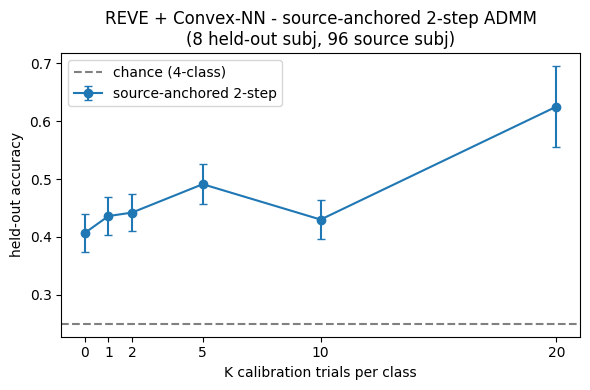

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(summary["k"], summary["acc_mean"], yerr=summary["sem"],
             marker="o", capsize=3, label="source-anchored 2-step")
ax.axhline(0.25, ls="--", color="grey", label="chance (4-class)")
ax.set_xlabel("K calibration trials per class")
ax.set_ylabel("held-out accuracy")
ax.set_title(f"REVE + Convex-NN - source-anchored 2-step ADMM\n({len(held_out_subjects)} held-out subj, {len(source_subjects)} source subj)")
ax.set_xticks(list(K_BUDGETS))
ax.legend()
fig.tight_layout()
fig.show()

## 7. EEGNet baseline

A compact CNN baseline: train once on source EEG, then for K > 0 fine-tune from the source weights using calibration trials plus a capped replay subset of source trials.

In [19]:
import pandas as pd
from tqdm import tqdm
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import torch.nn as nn
from scipy.signal import resample_poly
from torch.utils.data import DataLoader, TensorDataset
from src.models import EEGNetClf

_EEGNET_DOWN_FACTOR = TARGET_FS_REVE // EEGNET_TARGET_FS
assert TARGET_FS_REVE == EEGNET_TARGET_FS * _EEGNET_DOWN_FACTOR, (
    f"EEGNet downsample requires integer ratio; got {TARGET_FS_REVE}/{EEGNET_TARGET_FS}"
)

def _downsample_to_eegnet_fs(X: np.ndarray) -> np.ndarray:
    if _EEGNET_DOWN_FACTOR == 1:
        return X.astype(np.float32, copy=False)
    Xd = resample_poly(X, up=1, down=_EEGNET_DOWN_FACTOR, axis=-1).astype(np.float32)
    if Xd.shape[-1] > EEGNET_TRIAL_SAMPLES:
        Xd = Xd[..., :EEGNET_TRIAL_SAMPLES]
    elif Xd.shape[-1] < EEGNET_TRIAL_SAMPLES:
        pad = np.zeros(Xd.shape[:-1] + (EEGNET_TRIAL_SAMPLES,), dtype=Xd.dtype)
        pad[..., -Xd.shape[-1]:] = Xd
        Xd = pad
    return Xd

def trials_to_eeg_xy(trials: list[Trial]) -> tuple[np.ndarray, np.ndarray]:
    X = np.stack([t.eeg for t in trials], axis=0).astype(np.float32)
    X = _downsample_to_eegnet_fs(X)
    y = np.asarray([t.label for t in trials], dtype=np.int64)
    return X, y

def fit_eeg_scaler(X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    mean = X.mean(axis=(0, 2), keepdims=True).astype(np.float32)
    std = X.std(axis=(0, 2), keepdims=True).astype(np.float32)
    return mean, np.maximum(std, 1.0e-4)

def transform_eeg(X: np.ndarray, scaler: tuple[np.ndarray, np.ndarray]) -> np.ndarray:
    mean, std = scaler
    return ((X.astype(np.float32) - mean) / std).astype(np.float32)

def make_eegnet_model() -> torch.nn.Module:
    return EEGNetClf(
        n_channels=N_CHANNELS,
        n_samples=EEGNET_TRIAL_SAMPLES,
        n_classes=4,
        kernel_len=EEGNET_KERNEL_LEN,
        dropout=EEGNET_DROPOUT,
    )

def clone_eegnet_model(model: torch.nn.Module) -> torch.nn.Module:
    cloned = make_eegnet_model()
    cloned.load_state_dict({k: v.detach().cpu().clone() for k, v in model.state_dict().items()})
    return cloned

def train_eegnet_model(
    model: torch.nn.Module,
    X: np.ndarray,
    y: np.ndarray,
    *,
    epochs: int,
    lr: float,
    weight_decay: float = EEGNET_WEIGHT_DECAY,
    patience: int = EEGNET_PATIENCE,
    val_frac: float = 0.1,
    seed: int = SEED,
    verbose: bool = False,
) -> torch.nn.Module:
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)
    X = X.astype(np.float32)
    y = y.astype(np.int64)
    idx = rng.permutation(len(X))
    n_val = max(1, int(len(X) * val_frac)) if val_frac > 0 and len(X) >= 10 else 0
    val_idx = idx[:n_val]
    tr_idx = idx[n_val:]
    if len(tr_idx) == 0:
        tr_idx = idx
        val_idx = np.asarray([], dtype=np.int64)
    loader = DataLoader(
        TensorDataset(torch.from_numpy(X[tr_idx]).unsqueeze(1), torch.from_numpy(y[tr_idx])),
        batch_size=EEGNET_BATCH_SIZE,
        shuffle=True,
        drop_last=False,
    )
    device = torch.device(DEVICE)
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit = nn.CrossEntropyLoss()
    best_metric = float("inf")
    best_state = None
    bad = 0
    for epoch in tqdm(range(int(epochs))):
        model.train()
        running = 0.0
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            loss = crit(model(xb), yb)
            if not torch.isfinite(loss):
                raise RuntimeError(f"EEGNet non-finite loss at epoch {epoch}")
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            running += float(loss.item()) * len(xb)
        metric = running / max(1, len(tr_idx))
        val_acc = np.nan
        if len(val_idx):
            model.eval()
            with torch.no_grad():
                xva = torch.from_numpy(X[val_idx]).unsqueeze(1).to(device)
                yva = torch.from_numpy(y[val_idx]).to(device)
                logits = model(xva)
                metric = float(crit(logits, yva).item())
                val_acc = float((logits.argmax(1) == yva).float().mean().item())
        if verbose:
            print(f"  epoch {epoch:03d} metric={metric:.4f} val_acc={val_acc:.3f}")
        if metric < best_metric - 1.0e-5:
            best_metric = metric
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model.to(device)

@torch.no_grad()
def predict_eegnet(model: torch.nn.Module, X: np.ndarray, scaler: tuple[np.ndarray, np.ndarray]) -> np.ndarray:
    model.eval()
    device = torch.device(DEVICE)
    Xs = transform_eeg(X, scaler)
    preds = []
    for i in range(0, len(Xs), 256):
        xb = torch.from_numpy(Xs[i:i + 256]).unsqueeze(1).to(device)
        preds.append(model(xb).argmax(1).detach().cpu().numpy())
    return np.concatenate(preds, axis=0).astype(np.int64)

def build_eegnet_replay_trials(
    source_trials: list[Trial],
    calib_trials: list[Trial],
    *,
    seed: int,
    target_mass: float = STAGE2_TARGET_MASS,
) -> tuple[list[Trial], int, int]:
    if not calib_trials:
        return [], 0, 0
    rng = np.random.default_rng(seed)
    n_replay = min(
        len(source_trials),
        max(EEGNET_BATCH_SIZE, int(round(EEGNET_SOURCE_REPLAY_FRAC * len(source_trials)))),
    )
    src_idx = rng.choice(len(source_trials), size=n_replay, replace=False)
    replay = [source_trials[i] for i in src_idx]
    repeat = calibration_repeat_count(n_replay, len(calib_trials), target_mass=target_mass)
    return replay + calib_trials * repeat, repeat, n_replay

eegnet_df = pd.DataFrame()
eegnet_summary = pd.DataFrame()
if RUN_EEGNET_BASELINE:
    print("EEGNet: fitting source model...")
    X_src_eeg, y_src_eeg = trials_to_eeg_xy(source_trials)
    eeg_scaler = fit_eeg_scaler(X_src_eeg)
    eegnet_src_model = make_eegnet_model()
    t0 = time.time()
    eegnet_src_model = train_eegnet_model(
        eegnet_src_model,
        transform_eeg(X_src_eeg, eeg_scaler),
        y_src_eeg,
        epochs=EEGNET_SOURCE_EPOCHS,
        lr=EEGNET_LR,
        patience=EEGNET_PATIENCE,
        val_frac=0.1,
        seed=SEED,
    )
    print(f"  EEGNet source fit: {time.time() - t0:.1f}s")
    eegnet_rows = []
    for ho in held_out_subjects:
        ho_trials = get_trials(ho)
        if not ho_trials:
            continue
        Xh_eeg, yh_eeg = trials_to_eeg_xy(ho_trials)
        for k in K_BUDGETS:
            c_idx, e_idx = sample_k_per_class(Xh_eeg, yh_eeg, k, seed=SEED + ho)
            if len(e_idx) == 0:
                continue
            fit_t = 0.0
            calib_repeat = 0
            n_replay = 0
            if k == 0 or len(c_idx) == 0:
                model_k = eegnet_src_model
                tag = "source"
            else:
                calib_trials = [ho_trials[i] for i in c_idx]
                ft_trials, calib_repeat, n_replay = build_eegnet_replay_trials(
                    source_trials, calib_trials, seed=SEED + 10_000 * ho + k,
                )
                Xft, yft = trials_to_eeg_xy(ft_trials)
                model_k = clone_eegnet_model(eegnet_src_model)
                t0 = time.time()
                model_k = train_eegnet_model(
                    model_k,
                    transform_eeg(Xft, eeg_scaler),
                    yft,
                    epochs=EEGNET_FINETUNE_EPOCHS,
                    lr=EEGNET_FINETUNE_LR,
                    patience=max(3, EEGNET_PATIENCE // 2),
                    val_frac=0.0,
                    seed=SEED + ho + k,
                )
                fit_t = time.time() - t0
                tag = f"replay_ft,r={calib_repeat}"
            yhat = predict_eegnet(model_k, Xh_eeg[e_idx], eeg_scaler)
            acc = float((yhat == yh_eeg[e_idx]).mean())
            eegnet_rows.append(dict(
                held_out=ho, k=k, n_calib=int(len(c_idx)), n_eval=int(len(e_idx)),
                acc=acc, tag=tag, calib_repeat=int(calib_repeat), n_replay=int(n_replay),
            ))
            print(f"  EEGNet S{ho:03d} K={k:>3d} acc={acc:.3f} [{tag}, {fit_t:.1f}s]")
    eegnet_df = pd.DataFrame(eegnet_rows)
    eegnet_summary = (
        eegnet_df.groupby("k")["acc"]
        .agg(["mean", "std", "count"])
        .rename(columns={"mean": "acc_mean", "std": "acc_std", "count": "n_subjects"})
        .reset_index()
    )
    eegnet_summary["sem"] = eegnet_summary["acc_std"] / np.sqrt(eegnet_summary["n_subjects"].clip(lower=1))
eegnet_summary


EEGNet: fitting source model...


 16%|████████████████████████████▍                                                                                                                                                     | 8/50 [01:37<08:32, 12.20s/it]


  EEGNet source fit: 98.4s
  EEGNet S002 K=  0 acc=0.256 [source, 0.0s]


 83%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                             | 10/12 [00:43<00:08,  4.30s/it]


  EEGNet S002 K=  1 acc=0.256 [replay_ft,r=291, 43.3s]


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:48<00:00,  4.04s/it]


  EEGNet S083 K= 10 acc=0.240 [replay_ft,r=29, 48.7s]


 42%|██████████████████████████████████████████████████████████████████████████▏                                                                                                       | 5/12 [00:24<00:34,  4.87s/it]

  EEGNet S083 K= 20 acc=0.200 [replay_ft,r=15, 24.7s]


,k,acc_mean,acc_std,n_subjects,sem
0,0,0.247222,0.011501,8,0.004066
1,1,0.252907,0.023047,8,0.008148
2,2,0.251524,0.020549,8,0.007265
3,5,0.248214,0.013088,8,0.004627
4,10,0.245000,0.020702,8,0.007319
5,20,0.225000,0.103510,8,0.036596


/var/folders/30/sgn149mj6t12f1cskl1blnf40000gn/T/ipykernel_11250/3286587606.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


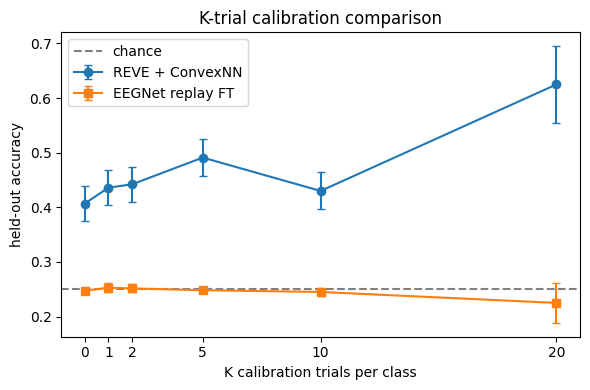

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(summary["k"], summary["acc_mean"], yerr=summary["sem"],
             marker="o", capsize=3, label="REVE + ConvexNN")
if len(eegnet_summary):
    ax.errorbar(eegnet_summary["k"], eegnet_summary["acc_mean"], yerr=eegnet_summary["sem"],
                 marker="s", capsize=3, label="EEGNet replay FT")
ax.axhline(0.25, ls="--", color="grey", label="chance")
ax.set_xlabel("K calibration trials per class")
ax.set_ylabel("held-out accuracy")
ax.set_title("K-trial calibration comparison")
ax.set_xticks(list(K_BUDGETS))
ax.legend()
fig.tight_layout()
fig.show()


## 8. Convex HP grid search

Grid-searches the two knobs that define the stage-2 objective: the target calibration mass and the convex group-lasso strength `beta`.

In [21]:
def run_convex_hp_grid(
    beta_grid: tuple[float, ...] = CVX_BETA_GRID,
    target_mass_grid: tuple[float, ...] = STAGE2_TARGET_MASS_GRID,
    k_budgets: tuple[int, ...] = HP_GRID_K_BUDGETS,
) -> pd.DataFrame:
    rows = []
    for beta in beta_grid:
        print(f"Grid beta={beta:g}: fitting source model...")
        t0 = time.time()
        grid_src_model, grid_src_scaler = fit_stage1_source(X_src, y_src, beta=beta)
        print(f"  source fit {time.time() - t0:.1f}s")
        for target_mass in target_mass_grid:
            print(f"  target_mass={target_mass:.2f}")
            for ho in held_out_subjects:
                Xh, yh = feature_cache[ho]
                if len(Xh) == 0:
                    continue
                for k in k_budgets:
                    c_idx, e_idx = sample_k_per_class(Xh, yh, k, seed=SEED + ho)
                    if len(e_idx) == 0 or len(c_idx) == 0:
                        continue
                    Xc, yc = Xh[c_idx], yh[c_idx]
                    Xe, ye = Xh[e_idx], yh[e_idx]
                    t_fit = time.time()
                    m = fit_stage2_source_anchored(
                        X_src, y_src, Xc, yc, grid_src_model, grid_src_scaler,
                        beta=beta, target_mass=target_mass,
                    )
                    yhat = convex_nn_predict(m, grid_src_scaler, Xe)
                    rows.append(dict(
                        cvx_beta=float(beta), stage2_target_mass=float(target_mass),
                        held_out=ho, k=k, n_calib=int(len(Xc)), n_eval=int(len(Xe)),
                        acc=float((yhat == ye).mean()), calib_repeat=int(m.calib_repeat),
                        actual_target_mass=float(m.stage2_target_mass), fit_s=time.time() - t_fit,
                    ))
    return pd.DataFrame(rows)

grid_results = pd.DataFrame()
grid_summary = pd.DataFrame()
grid_overall = pd.DataFrame()
if RUN_CVX_HP_GRID:
    grid_results = run_convex_hp_grid()
    grid_summary = (
        grid_results.groupby(["cvx_beta", "stage2_target_mass", "k"])["acc"]
        .agg(["mean", "std", "count"])
        .rename(columns={"mean": "acc_mean", "std": "acc_std", "count": "n_subjects"})
        .reset_index()
    )
    grid_summary["sem"] = grid_summary["acc_std"] / np.sqrt(grid_summary["n_subjects"].clip(lower=1))
    grid_overall = (
        grid_results.groupby(["cvx_beta", "stage2_target_mass"])["acc"]
        .mean()
        .reset_index(name="acc_mean")
        .sort_values("acc_mean", ascending=False)
    )
grid_overall.head(10)


Grid beta=0.0003: fitting source model...
  source fit 3.1s
  target_mass=0.15
  target_mass=0.35
  target_mass=0.55
Grid beta=0.001: fitting source model...
  source fit 3.1s
  target_mass=0.15
  target_mass=0.35
  target_mass=0.55
Grid beta=0.003: fitting source model...
  source fit 3.2s
  target_mass=0.15
  target_mass=0.35
  target_mass=0.55


,cvx_beta,stage2_target_mass,acc_mean
6,0.0030,0.15,0.489481
1,0.0003,0.35,0.485311
0,0.0003,0.15,0.485133
4,0.0010,0.35,0.484838
3,0.0010,0.15,0.484633
7,0.0030,0.35,0.484191
5,0.0010,0.55,0.477133
8,0.0030,0.55,0.476805
2,0.0003,0.55,0.474018


/var/folders/30/sgn149mj6t12f1cskl1blnf40000gn/T/ipykernel_11250/1821009587.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


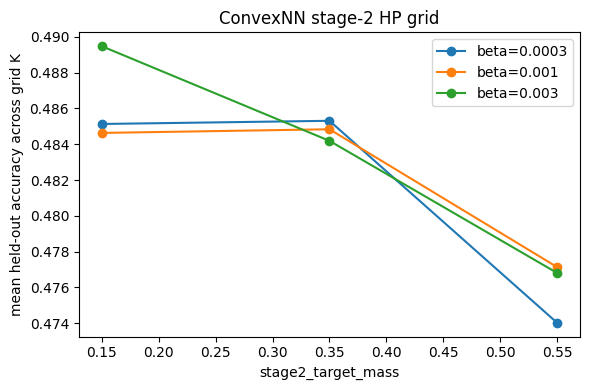

In [22]:
if len(grid_summary):
    fig, ax = plt.subplots(figsize=(6, 4))
    for beta, sub in grid_overall.groupby("cvx_beta"):
        sub = sub.sort_values("stage2_target_mass")
        ax.plot(sub["stage2_target_mass"], sub["acc_mean"], marker="o", label=f"beta={beta:g}")
    ax.set_xlabel("stage2_target_mass")
    ax.set_ylabel("mean held-out accuracy across grid K")
    ax.set_title("ConvexNN stage-2 HP grid")
    ax.legend()
    fig.tight_layout()
    fig.show()


## 9. Save artifacts

In [ ]:
out_dir = REPO_ROOT / "results" / "reve_kmin_convexnn_v3_nb"
out_dir.mkdir(parents=True, exist_ok=True)
stamp = time.strftime("%Y%m%d-%H%M%S")
df.to_csv(out_dir / f"per_split_{stamp}.csv", index=False)
summary.to_csv(out_dir / f"summary_{stamp}.csv", index=False)
if "eegnet_df" in globals() and len(eegnet_df):
    eegnet_df.to_csv(out_dir / f"eegnet_per_split_{stamp}.csv", index=False)
    eegnet_summary.to_csv(out_dir / f"eegnet_summary_{stamp}.csv", index=False)
if "grid_results" in globals() and len(grid_results):
    grid_results.to_csv(out_dir / f"convex_hp_grid_per_split_{stamp}.csv", index=False)
    grid_summary.to_csv(out_dir / f"convex_hp_grid_summary_{stamp}.csv", index=False)
    grid_overall.to_csv(out_dir / f"convex_hp_grid_overall_{stamp}.csv", index=False)
print("wrote:", out_dir)